In [ ]:
#pip install lightgbm xgboost

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

train = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\train.csv")
test = pd.read_csv(r"C:\Users\mpkhd\Desktop\Uni\4th year\Sem1\ST4052\Project1\Advanced\test.csv")

# categorical columns set as type 'category'

train = train.astype({'Gender': 'category','EducationLevel':'category',
                'RecruitmentStrategy':'category', 'HiringDecision':'category'})
test = test.astype({'Gender': 'category','EducationLevel':'category',
                'RecruitmentStrategy':'category', 'HiringDecision':'category'})

In [75]:
#train.info()

In [77]:
X = train.drop(columns = 'HiringDecision')
y = train['HiringDecision']
X_test = test.drop(columns = 'HiringDecision')

In [3]:
import lightgbm as lgb
import xgboost as xgb

# XGB

In [ ]:
xgb1 = xgb.XGBClassifier(enable_categorical=True)

In [ ]:
xgb1.fit(X,y)

In [ ]:
xgb1.get_params()

In [ ]:
yhat = xgb1.predict(X_test)

In [ ]:
explainerOver = shap.Explainer(xgb1)
shap_values = explainerOver(X)


In [ ]:
print(metrics.confusion_matrix(yhat,test['HiringDecision']))

In [ ]:
metrics.precision_score(yhat,test['HiringDecision'])

In [ ]:
metrics.recall_score(yhat,test['HiringDecision'])

In [ ]:
#xgb1.get_params()

In [9]:
from skopt import BayesSearchCV
from xgboost import XGBClassifier
from skopt.space import Real, Integer, Categorical

In [ ]:
search_space = {
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'n_estimators': Integer(50, 1000),
    'max_depth': Integer(3, 10),
    'min_child_weight': Integer(1, 10),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 10),
    'reg_alpha': Real(0, 1),
    'reg_lambda': Real(0, 1)
}

opt = BayesSearchCV(
    XGBClassifier(enable_categorical=True, use_label_encoder=False, eval_metric='logloss'),
    search_space,
    n_iter=50,
    cv=5,
    n_jobs=-1
)

opt.fit(X, y)  

In [ ]:
opt.best_params_

In [ ]:
best_params = opt.best_params_
best_XGB = XGBClassifier(**best_params,enable_categorical=True)
best_XGB.fit(X, y)
best_XGBvals = best_XGB.predict(X_test)

In [ ]:
print(metrics.confusion_matrix(best_XGBvals,test['HiringDecision']))

In [ ]:
opt.cv_results_['std_test_score']

In [ ]:
#pip install shap

# LGB

In [48]:
lgb1 = lgb.LGBMClassifier()

In [50]:
lgb1.fit(X,y)

[LightGBM] [Info] Number of positive: 372, number of negative: 828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310000 -> initscore=-0.800119
[LightGBM] [Info] Start training from score -0.800119


LGBMClassifier()

In [250]:
# lgb1.get_params()

In [54]:
yhat = lgb1.predict(X_test)

In [252]:
# search_spacel = {
#     'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
#     'n_estimators': Integer(50, 1000),
#     'max_depth': Integer(3, 15),
#     'num_leaves': Integer(7, 256),
#     'min_child_samples': Integer(5, 100),
#     'subsample': Real(0.5, 1.0),                  
#     'colsample_bytree': Real(0.5, 1.0),           
#     'reg_alpha': Real(0.0, 1.0),                 
#     'reg_lambda': Real(0.0, 1.0),                 
#     'boosting_type': Categorical(['gbdt', 'dart', 'goss'])
# }


# optl = BayesSearchCV(
#     lgb.LGBMClassifier(),
#     search_spacel,
#     n_iter=50,
#     cv=5,
#     n_jobs=-1
# )

# optl.fit(X, y)  

In [56]:
print(metrics.confusion_matrix(yhat,test['HiringDecision']))

[[202  17]
 [  5  76]]


In [79]:
params = optl.best_params_  

In [270]:
optl.best_params_ 

OrderedDict([('boosting_type', 'goss'),
             ('colsample_bytree', 0.5),
             ('learning_rate', 0.045425969545453554),
             ('max_depth', 3),
             ('min_child_samples', 100),
             ('n_estimators', 871),
             ('num_leaves', 176),
             ('reg_alpha', 1.0),
             ('reg_lambda', 0.1655033647164616),
             ('subsample', 0.8216357649376596)])

In [264]:
# from lightgbm import LGBMClassifier
# best_paramsl = optl.best_params_
# best_LGB = LGBMClassifier(**best_paramsl)
# best_LGB.fit(X, y)
# best_LGBvals = best_LGB.predict(X_test)

In [80]:
import joblib

In [148]:
#joblib.dump(best_LGB, 'best_lgb_model.pkl')
best_LGB = joblib.load('lgb_model.pkl')

In [150]:
best_LGBvals = best_LGB.predict(X_test)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


In [152]:
print(metrics.confusion_matrix(best_LGBvals,test['HiringDecision']))

[[204  14]
 [  3  79]]


In [266]:
# best_LGB.booster_.save_model('lgb_model.txt')

# One Hot Encoding

In [102]:
X_encoded = pd.get_dummies(X, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, drop_first=False)

In [110]:
#best_LGB.fit(X_encoded,y)

In [106]:
yhat_encode = best_LGB.predict(X_test_encoded)

[LightGBM] [Warning] Found boosting=goss. For backwards compatibility reasons, LightGBM interprets this as boosting=gbdt, data_sample_strategy=goss.To suppress this warning, set data_sample_strategy=goss instead.


In [128]:
yhat_encode

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], d

In [108]:
metrics.confusion_matrix(yhat_encode,test['HiringDecision'])

array([[203,  15],
       [  4,  78]], dtype=int64)

# Shap

In [66]:
import shap
import numpy as np

In [154]:
explainer = shap.Explainer(best_LGB)
shap_values = explainer(X_test)

In [156]:
np.shape(shap_values.values)

(300, 10)

In [158]:
shap.initjs()

In [142]:
test.iloc[2]

Age                    27.000000
Gender                  1.000000
EducationLevel          3.000000
ExperienceYears         1.000000
PreviousCompanies       2.000000
DistanceFromCompany    43.547595
InterviewScore         96.000000
SkillScore             71.000000
PersonalityScore       96.000000
RecruitmentStrategy     2.000000
HiringDecision          1.000000
Name: 2, dtype: float64

In [160]:
# shap.plots.waterfall(shap_values[2])

In [98]:
# for 1st observation
shap.plots.waterfall(shap_values[0], show=False)
plt.savefig("shap_waterfall.png", bbox_inches='tight', dpi=300)
plt.close()

In [143]:
shap.plots.force(shap_values[0])

In [199]:
import plotly.io as pio

In [155]:
shap.plots.force(shap_values[0:299])

In [210]:
# import plotly.io as pio

# fig = shap.plots.bar(shap_values, show=False)
# pio.write_image(fig, "mean_shap_values.png", width=800, height=600, scale=2)

In [162]:
shap.plots.bar(shap_values, show=False)
plt.savefig("shap_bar_collectively.png", bbox_inches='tight', dpi=300)
plt.close()

In [100]:
shap.plots.beeswarm(shap_values,show=False)
plt.savefig("shap_beeswarm.png", bbox_inches='tight', dpi=300)
plt.close()

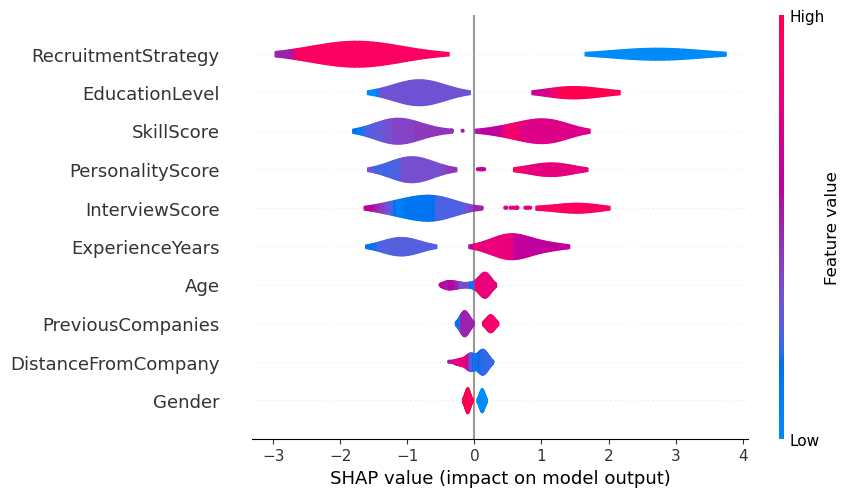

In [149]:
shap.plots.violin(shap_values)

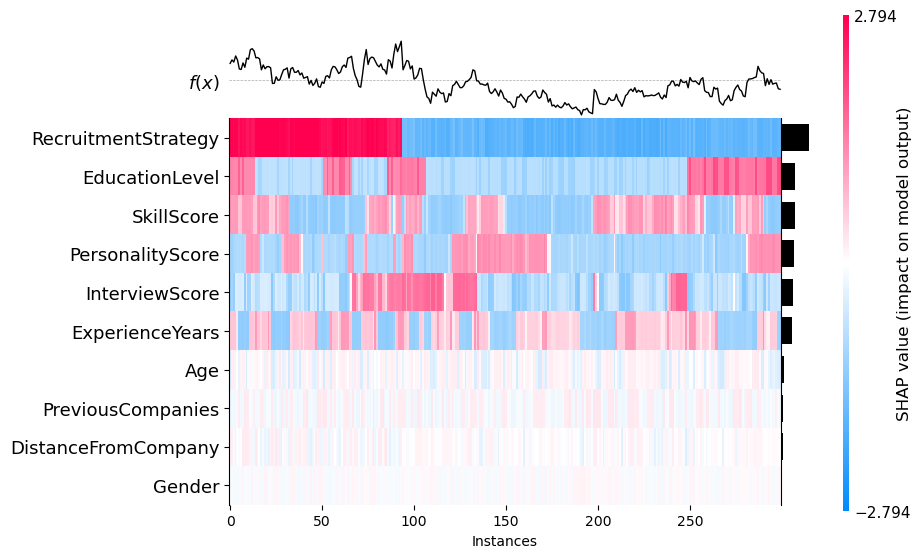

<Axes: xlabel='Instances'>

In [151]:
shap.plots.heatmap(shap_values)

## Encoded Shap

In [112]:
explainer = shap.Explainer(best_LGB)
shap_values = explainer(X_test_encoded)

In [120]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.savefig("shap_beeswarm.png", bbox_inches='tight', dpi=300)
plt.close()

In [124]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.savefig("shap_bar.png", bbox_inches='tight', dpi=300)
plt.close()

In [126]:
shap.plots.waterfall(shap_values[0], max_display=20, show=False)
plt.savefig("shap_waterfall.png", bbox_inches='tight', dpi=300)
plt.close()

# Dependence Plots

In [160]:
# shap.plots.scatter(shap_values[:,'RecruitmentStrategy'])

In [164]:
# shap.plots.scatter(shap_values[:,'Age'])

# Only With the top 6 most Contributing Variables according to Shap

In [97]:
#X_Select = train.drop(columns = {'HiringDecision', 'Gender', 'Age', 'ExperienceYears', 'PreviousCompanies'})
#X_test_Select = test.drop(columns = {'HiringDecision', 'Gender', 'Age', 'ExperienceYears', 'PreviousCompanies'})

In [103]:
# search_spacel_Select = {
#     'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
#     'n_estimators': Integer(50, 1000),
#     'max_depth': Integer(3, 15),
#     'num_leaves': Integer(7, 256),
#     'min_child_samples': Integer(5, 100),
#     'subsample': Real(0.5, 1.0),                
#     'colsample_bytree': Real(0.5, 1.0),           
#     'reg_alpha': Real(0.0, 1.0),                 
#     'reg_lambda': Real(0.0, 1.0),                 
#     'boosting_type': Categorical(['gbdt', 'dart', 'goss'])
# }


# optl_Select = BayesSearchCV(
#     lgb.LGBMClassifier(),
#     search_spacel,
#     n_iter=50,
#     cv=5,
#     n_jobs=-1
# )

# optl_Select.fit(X_Select, y) 

[LightGBM] [Info] Number of positive: 372, number of negative: 828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000129 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 567
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310000 -> initscore=-0.800119
[LightGBM] [Info] Start training from score -0.800119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

BayesSearchCV(cv=5, estimator=LGBMClassifier(), n_jobs=-1,
              search_spaces={'boosting_type': Categorical(categories=('gbdt', 'dart', 'goss'), prior=None),
                             'colsample_bytree': Real(low=0.5, high=1.0, prior='uniform', transform='normalize'),
                             'learning_rate': Real(low=0.01, high=0.3, prior='log-uniform', transform='normalize'),
                             'max_depth': Integer(low=3, high=15, prior='un...
                             'n_estimators': Integer(low=50, high=1000, prior='uniform', transform='normalize'),
                             'num_leaves': Integer(low=7, high=256, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0, high=1.0, prior='uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.0, high=1.0, prior='uniform', transform='normalize'),
                             'subsample': Real(low=0.5, high=1.0, prior='uniform', transform='normalize')})

In [105]:
# best_paramsl = optl_Select.best_params_
# best_LGB_Select = LGBMClassifier(**best_paramsl)
# best_LGB_Select.fit(X_Select, y)
# best_LGB_Select_vals = best_LGB_Select.predict(X_test_Select)

[LightGBM] [Info] Number of positive: 372, number of negative: 828
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000142 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 567
[LightGBM] [Info] Number of data points in the train set: 1200, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.310000 -> initscore=-0.800119
[LightGBM] [Info] Start training from score -0.800119
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [107]:
# print(metrics.confusion_matrix(best_LGB_Select_vals,test['HiringDecision']))

[[191  25]
 [ 16  68]]


In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

import matplotlib.pyplot as plt

def evaluate_classification_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC AUC: {roc_auc:.4f}")
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
evaluate_classification_model(best_LGB, X_test, test['HiringDecision'])

In [ ]:
evaluate_classification_model(best_LGB, X, y)

In [ ]:
evaluate_classification_model(best_XGB, X_test, test['HiringDecision'])

In [ ]:
evaluate_classification_model(best_XGB, X, y)